# 3 激活函数

学习目标
- 理解非线性因素
- 知道常见激活函数

## 1. 网络非线性因素的理解

激活函数用于对每层的输出数据进行变换，进而为整个网络结构注入了非线性因素。此时，神经网络就可以拟合各种曲线。如果不使用激活函数，整个网络虽然看起来复杂，其本质还相当于一种线性模型，如下公式所示：

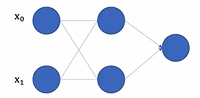

$$f_{c1} = w_0^{c1}x_0 + w_1^{c1}x_1 + b^{c1}$$

$$f_{c2} = w_0^{c2}x_0 + w_1^{c2}x_1 + b^{c2}$$

$$f_{\text{out}} = w_0^{\text{out}}f_{c1} + w_1^{\text{out}}f_{c2} + b^{\text{out}}$$

$$= w_0^{\text{out}}(w_0^{c1}x_0 + w_1^{c1}x_1 + b^{c1}) + w_1^{\text{out}}(w_0^{c2}x_0 + w_1^{c2}x_1 + b^{c2}) + b^{\text{out}}$$
$$= (w_0^{\text{out}}w_0^{c1} + w_1^{\text{out}}w_0^{c2})x_0 + (w_0^{\text{out}}w_1^{c1} + w_1^{\text{out}}w_1^{c2})x_1 + (w_0^{\text{out}}b^{c1} + w_1^{\text{out}}b^{c2} + b^{\text{out}})$$

$$k_0 = w_0^{\text{out}}w_0^{c1} + w_1^{\text{out}}w_0^{c2}$$
$$k_1 = w_0^{\text{out}}w_1^{c1} + w_1^{\text{out}}w_1^{c2}$$
$$c = w_0^{\text{out}}b^{c1} + w_1^{\text{out}}b^{c2} + b^{\text{out}}$$

$$= k_0x_0 + k_1x_1 + c$$

1. 没有引入非线性因素的网络等价于使用一个线性模型来拟合

2. 通过给网络输出增加激活函数，实现引入非线性因素，使得网络模型可以逼近任意函数，提升网络对复杂问题的拟合能力。

另外通过图像可视化的形式理解：

神经网络可视化

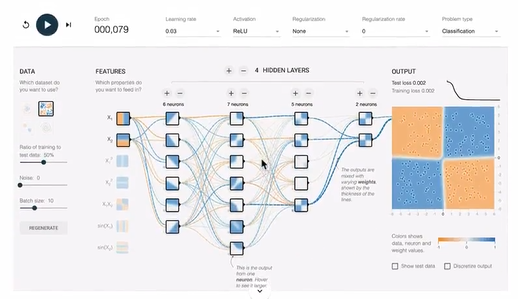

我们发现增加激活函数之后，对于线性不可分的场景，神经网络的拟合能力更强。

## 2. 常见的激活函数

激活函数主要用来向神经网络中加入非线性因素，以解决线性模型表达能力不足的问题，它对神经网络有着极其重要的作用。我们的网络参数在更新时，使用的是反向传播算法（BP），这就要求我们的激活函数必须可微。

### 2.1 sigmoid 激活函数

$$f(x) = \frac{1}{1 + e^{-x}}$$

sigmoid 激活函数的函数图像如下：

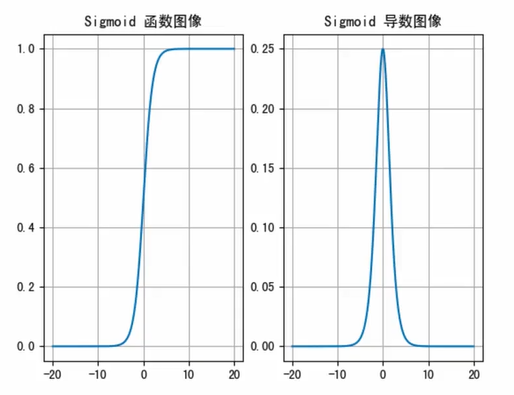

从 sigmoid 函数图像可以得到，sigmoid 函数可以将任意的输入映射到 (0, 1) 之间，当输入的值大致在 <-6 或者 >6 时，意味着输入任何值得到的激活值都是差不多的，这样会丢失部分的信息。比如：输入 100 和输出 10000 经过 sigmoid 的激活值几乎都是等于 1 的，但是输入的数据之间相差 100 倍的信息就丢失了。

对于 sigmoid 函数而言，输入值在 [-6, 6] 之间输出值才会有明显差异，输入值在 [-3, 3] 之间才会有比较好的效果。

通过上述导数图像，我们发现导数值范围是 (0, 0.25)，当输入 <-6 或者 >6 时，sigmoid 激活函数图像的导数接近为 0，此时网络参数将更新极其缓慢，或者无法更新。

一般来说，sigmoid 网络在 5 层之内就会产生梯度消失现象。而且，该激活函数并不是以 0 为中心的，所以在实践中这种激活函数使用的很少。sigmoid 函数一般只用于二分类的输出层。

在 PyTorch 中使用 sigmoid 函数的示例代码如下：

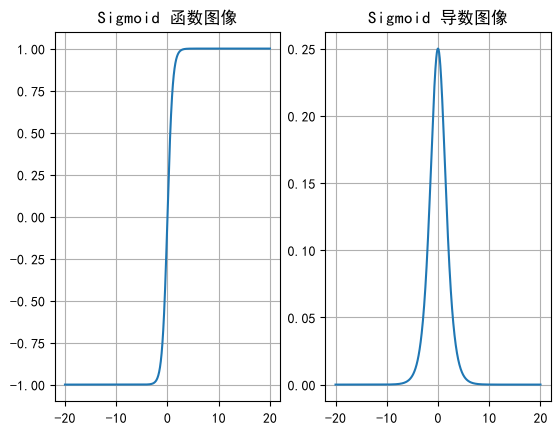

In [7]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

# 1. 解决中文显示问题（设置全局字体为黑体）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
# 2. 解决坐标轴负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

def test():
    _, axes = plt.subplots(1, 2)

    # 函数图像
    x = torch.linspace(-20, 20, 1000)
    y = F.tanh(x)
    axes[0].plot(x, y)
    axes[0].grid()
    axes[0].set_title('Sigmoid 函数图像')

    # 导数图像
    x = torch.linspace(-20, 20, 1000, requires_grad=True)
    torch.sigmoid(x).sum().backward()

    axes[1].plot(x.detach(), x.grad)
    axes[1].grid()
    axes[1].set_title('Sigmoid 导数图像')

    plt.show()


if __name__ == '__main__':
    test()

### 2.2 tanh 激活函数

Tanh 叫做双曲正切函数，其公式如下：

$$f(x) = \frac{1 - e^{-2x}}{1 + e^{-2x}}$$

Tanh 的函数图像、导数图像如下：

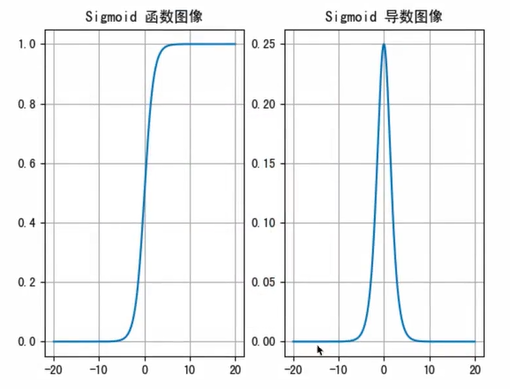

由上面的函数图像可以看到，Tanh 函数将输入映射到 (-1, 1) 之间，图像以 0 为中心，在 0 点对称，当输入大概 <-3 或者 >3 时将被映射为 -1 或者 1。其导数值范围 (0, 1)，当输入的值大概 <-3 或者 >3 时，其导数近似 0。

与 Sigmoid 相比，它是以 0 为中心的，使得其收敛速度要比 Sigmoid 快，减少迭代次数。然而，从图中可以看出，Tanh 两侧的导数也为 0，同样会造成梯度消失。

若使用时可在隐藏层使用 tanh 函数，在输出层使用 sigmoid 函数。

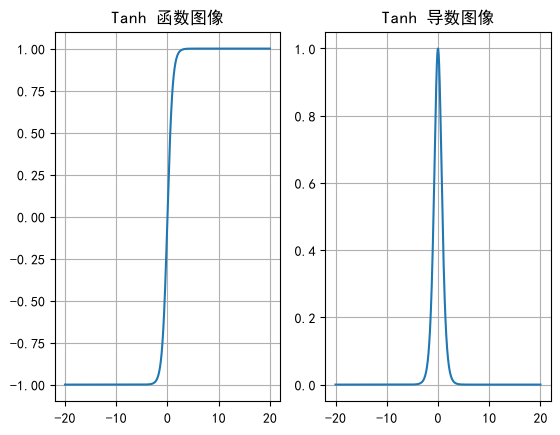

In [6]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

# 1. 解决中文显示问题（设置全局字体为黑体）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
# 2. 解决坐标轴负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

def test():
    _, axes = plt.subplots(1, 2)

    # 函数图像
    x = torch.linspace(-20, 20, 1000)
    y = F.tanh(x)
    axes[0].plot(x, y)
    axes[0].grid()
    axes[0].set_title('Tanh 函数图像')

    # 导数图像
    x = torch.linspace(-20, 20, 1000, requires_grad=True)
    F.tanh(x).sum().backward()

    axes[1].plot(x.detach(), x.grad)
    axes[1].grid()
    axes[1].set_title('Tanh 导数图像')

    plt.show()


if __name__ == '__main__':
    test()

### 2.3 ReLU 激活函数

ReLU 激活函数公式如下：

$$f(x) = \max(0, x)$$

函数图像如下：

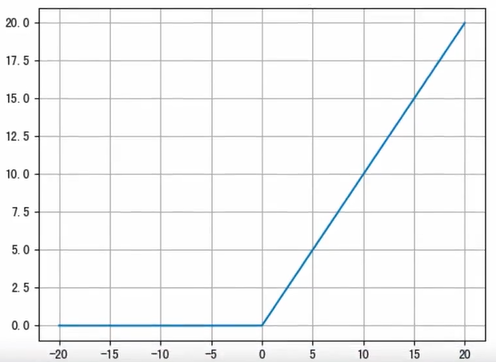

从上述函数图像可知，ReLU 激活函数将小于 0 的值映射为 0，而大于 0 的值则保持不变，它更加重视正信号，而忽略负信号，这种激活函数运算更为简单，能够提高模型的训练效率。

但是，如果我们网络的参数采用随机初始化时，很多参数可能为负数，这就使得输入的负值会被舍去，而输入的正值则会保留，这可能在大部分的情况下并不是我们想要的结果。

ReLU 的导数图像如下：

ReLU是目前最常用的激活函数。从图中可以看到，当x<0时，ReLU导数为0，而当x>0时，则不存在饱和问题。所以，ReLU能够在x>0时保持梯度不衰减，从而缓解梯度消失问题。然而，随着训练的推进，部分输入会落入小于0区域，导致对应权重无法更新。这种现象被称为“神经元死亡”。

与sigmoid相比，RELU的优势是：

采用sigmoid函数，计算量大（指数运算），反向传播求误差梯度时，求导涉及除法，计算量相对大，而采用Relu激活函数，整个过程的计算量节省很多。sigmoid函数反向传播时，很容易就会出现梯度消失的情况，从而无法完成深层网络的训练。Relu会使一部分神经元的输出为0，这样就造成了网络的稀疏性，并且减少了参数的相互依存关系，缓解了过拟合问题的发生。

## 2.4 SoftMax

softmax用于多分类过程中，它是二分类函数sigmoid在多分类上的推广，目的是将多分类的结果以概率的形式展现出来。

计算方法如下图所示：

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

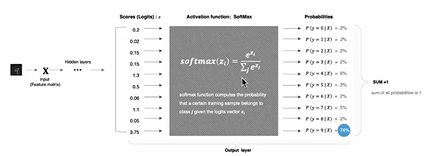

Softmax 直白来说就是将网络输出的 logits 通过 softmax 函数，就映射成为 (0,1) 的值，而这些值的累和为 1（满足概率的性质），那么我们将它理解成概率，选取概率最大（也就是值对应最大的）节点，作为我们的预测目标类别。

In [9]:
import torch

if __name__ == '__main__':
    scores = torch.tensor([0.2, 0.02, 0.15, 0.15, 1.3, 0.5, 0.06, 1.1, 0.05, 3.75])
    probabilities = torch.softmax(scores, dim=0)
    print(probabilities)
    print(probabilities.sum())

tensor([0.0212, 0.0177, 0.0202, 0.0202, 0.0638, 0.0287, 0.0185, 0.0522, 0.0183,
        0.7392])
tensor(1.0000)
